In [2]:
# -*- coding: utf-8 -*-
"""
ПОЛНЫЙ АНАЛИЗ И ПРОГНОЗИРОВАНИЕ ЭЛЕКТРОПОТРЕБЛЕНИЯ
с использованием модели N-BEATSx для ВКР

Версия с расширенным набором метрик (MAE, RMSE, MAPE, MASE),
оптимизированным итеративным прогнозом и автоматическим сохранением
результатов в отдельную папку с датой и временем запуска.
"""

# =============================================================================
# 1. ИМПОРТ БИБЛИОТЕК И НАСТРОЙКА ОКРУЖЕНИЯ
# =============================================================================

import os
import gc
import time
import warnings
import logging
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_absolute_percentage_error as MAPE
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATSx
from neuralforecast.losses.pytorch import MAE as MAE_torch

# Подавление лишних логов PyTorch Lightning
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Palatino Linotype'
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# Создание основной папки для результатов с меткой времени
run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = f"run_{run_timestamp}"
PICTURES_DIR = os.path.join(RUN_DIR, "pictures")
RESULTS_DIR = os.path.join(RUN_DIR, "results")
os.makedirs(PICTURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Результаты будут сохранены в папку: {RUN_DIR}")

2026-03-19 22:00:20,706	INFO util.py:154 -- Outdated packages:
  ipywidgets==7.8.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-03-19 22:00:20,935	INFO util.py:154 -- Outdated packages:
  ipywidgets==7.8.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Результаты будут сохранены в папку: run_20260319_220021


In [3]:
# =============================================================================
# 2. ЗАГРУЗКА ДАННЫХ И ПЕРВИЧНЫЙ ОСМОТР
# =============================================================================

file_path = 'DataBase.xlsx'
try:
    df = pd.read_excel(file_path, decimal=',')
    print(f"Файл '{file_path}' успешно загружен.")
except FileNotFoundError:
    print(f"Ошибка: файл '{file_path}' не найден.")
    raise

print("\n" + "=" * 50)
print("ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ")
print("=" * 50)
print(f"Размер датасета: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")
df.info()
print("\nПервые 5 строк:")
print(df.head())
print("\nОписательная статистика:")
print(df.describe())
print("\nПропуски:")
print(df.isnull().sum())

if not pd.api.types.is_datetime64_any_dtype(df['Date']):
    df['Date'] = pd.to_datetime(df['Date'])

Файл 'DataBase.xlsx' успешно загружен.

ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ
Размер датасета: (109032, 13)
Колонки: ['Date', 'Year', 'Month', 'Day', 'Hour', 'Weekday', 'Volume', 'Temperature', 'PredCons', 'ActCons', 'PredGen', 'ActGen', 'Price']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109032 entries, 0 to 109031
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Date         109032 non-null  datetime64[ns]
 1   Year         109032 non-null  int64         
 2   Month        109032 non-null  int64         
 3   Day          109032 non-null  int64         
 4   Hour         109032 non-null  int64         
 5   Weekday      109032 non-null  int64         
 6   Volume       109032 non-null  float64       
 7   Temperature  109032 non-null  float64       
 8   PredCons     109032 non-null  int64         
 9   ActCons      109032 non-null  int64         
 10  PredGen      109032 non-null  int64         
 11  A


ДЕТАЛЬНЫЙ АНАЛИЗ ВРЕМЕННОГО РЯДА


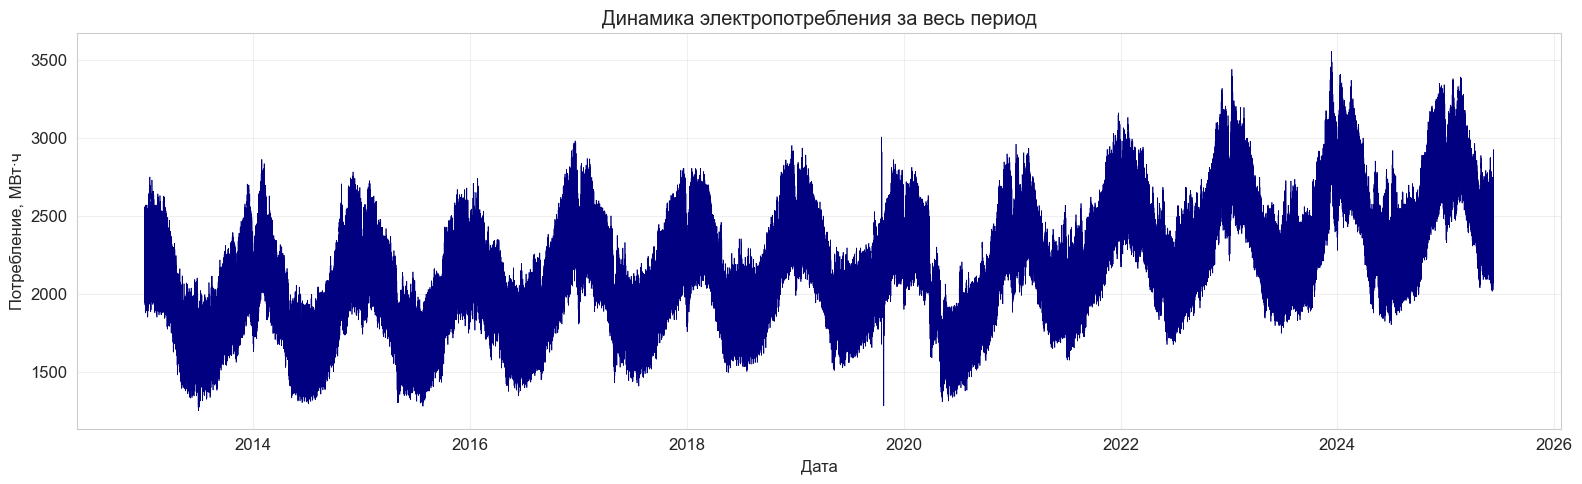

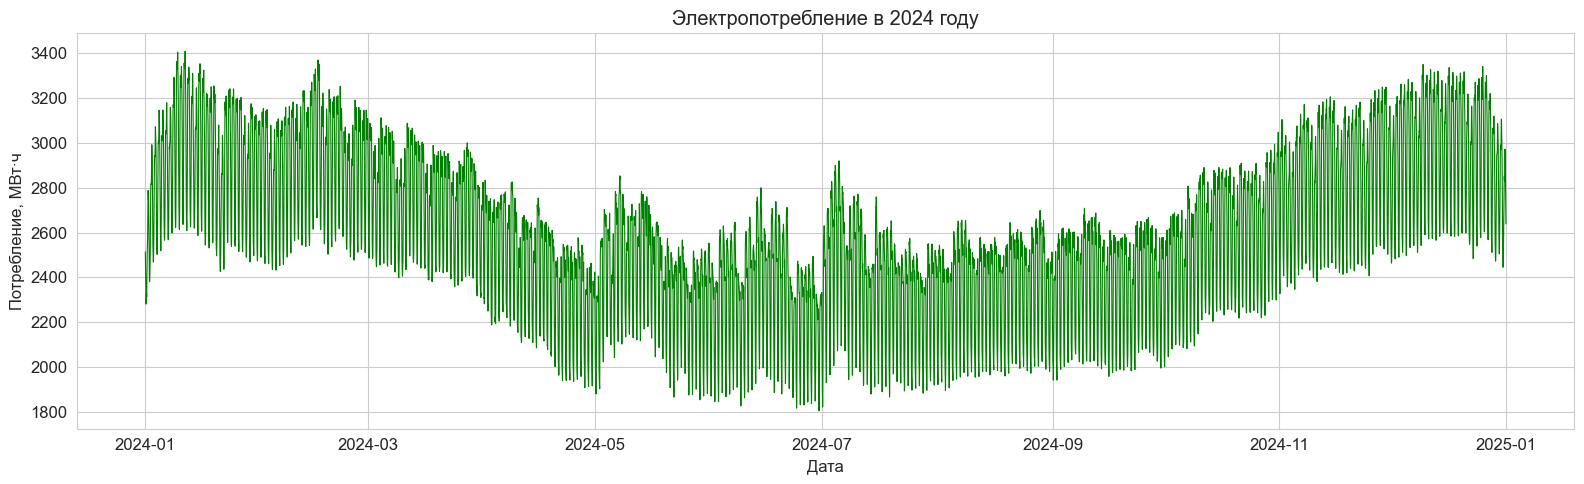

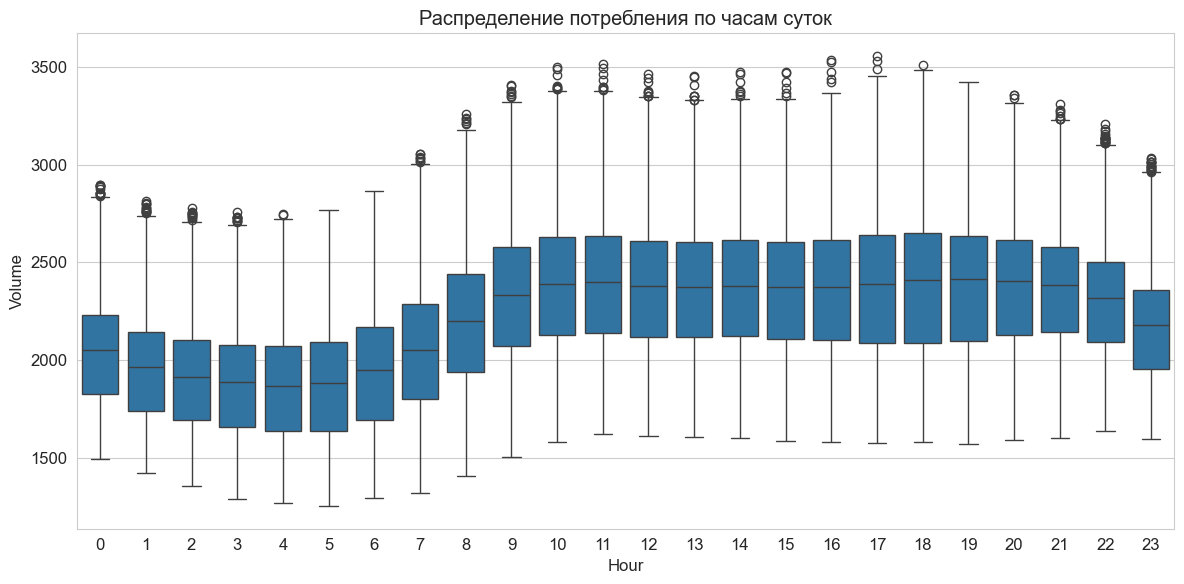

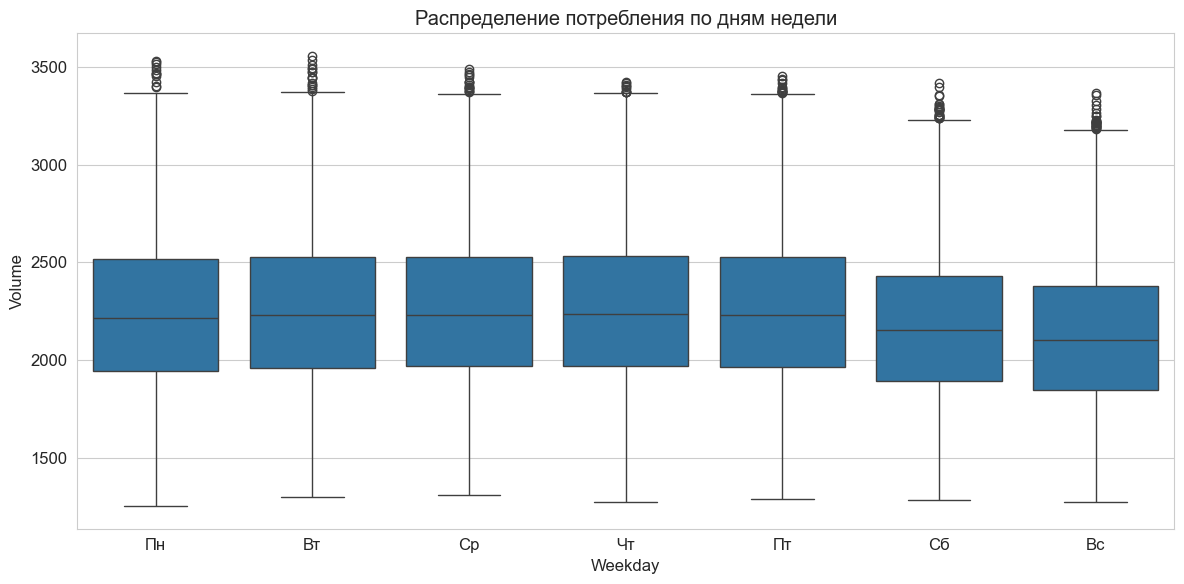

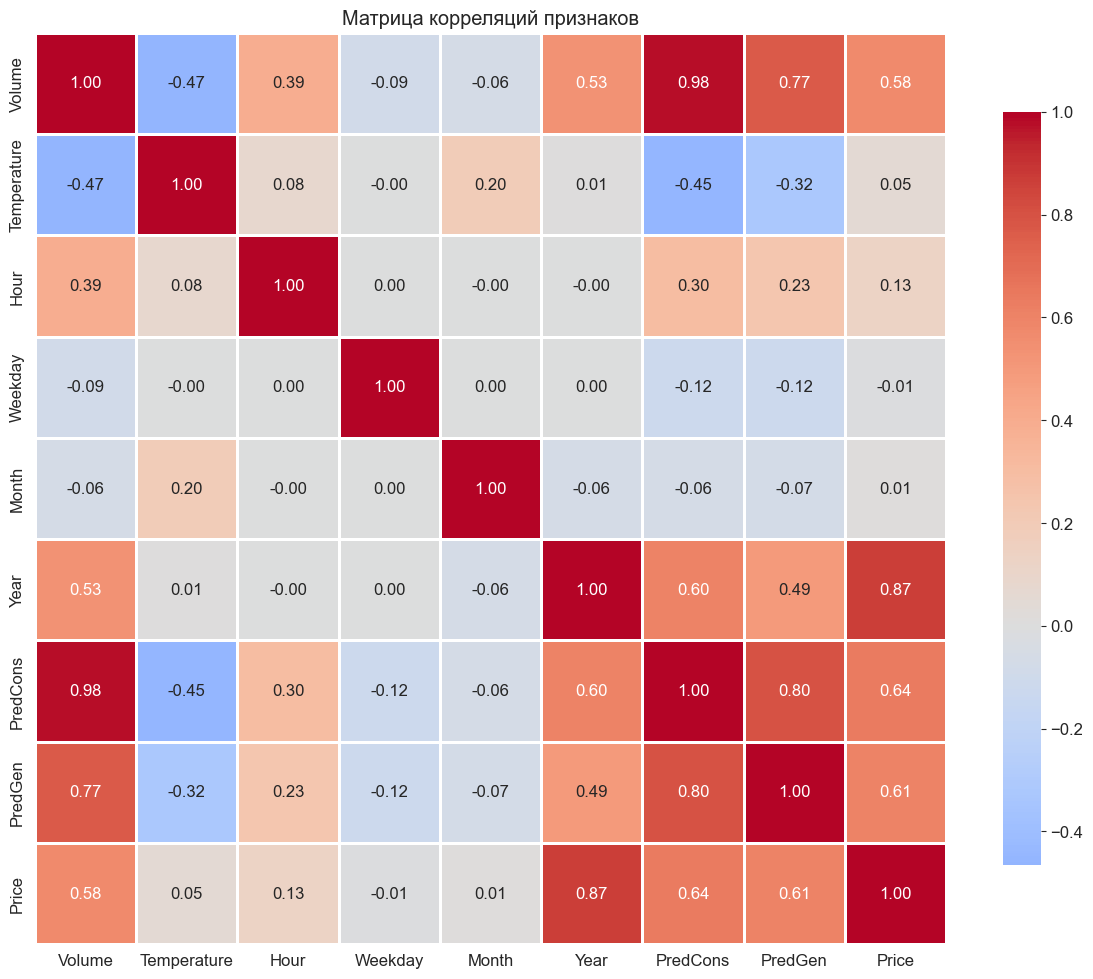


Корреляции с Volume:
Volume         1.000000
PredCons       0.975273
PredGen        0.766306
Price          0.576227
Year           0.530791
Hour           0.388490
Month         -0.060513
Weekday       -0.090580
Temperature   -0.465778
Name: Volume, dtype: float64

Тест на стационарность (ADF):
ADF Statistic: -4.606869, p-value: 0.000125
✅ Ряд стационарен


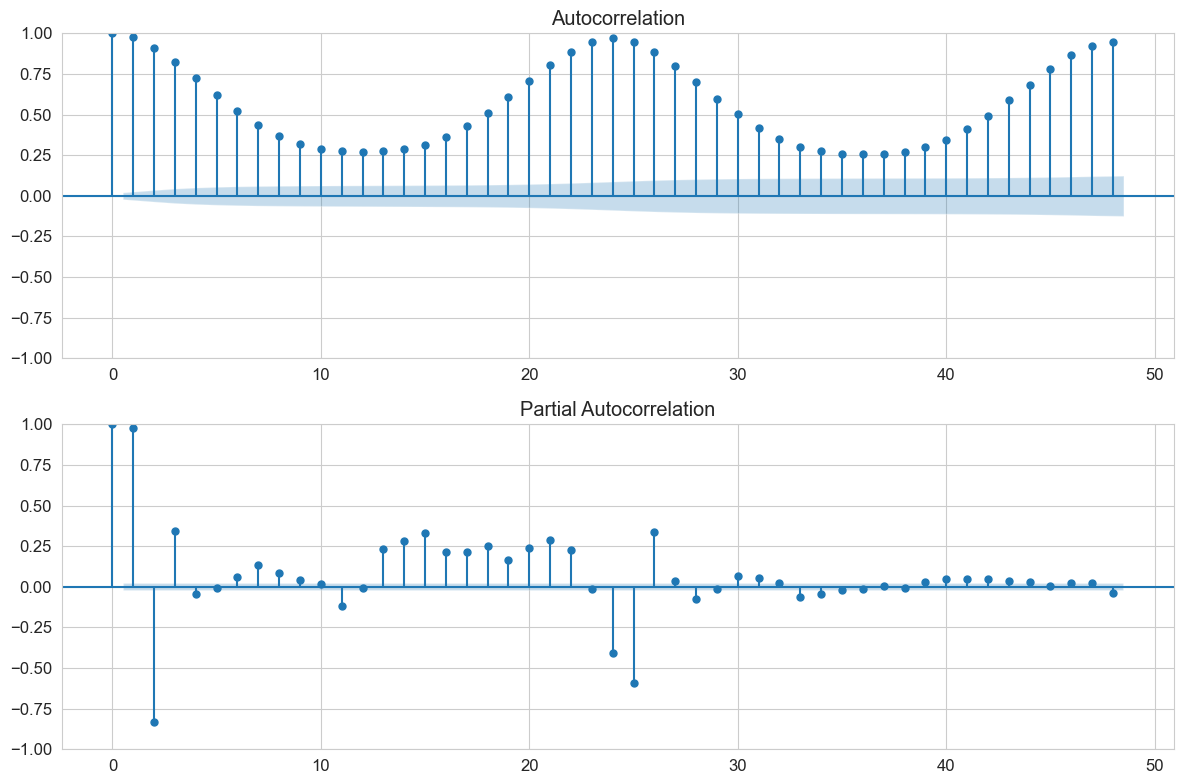

In [58]:
# =============================================================================
# 3. ДЕТАЛЬНЫЙ АНАЛИЗ ВРЕМЕННОГО РЯДА (EDA)
# =============================================================================

print("\n" + "=" * 50)
print("ДЕТАЛЬНЫЙ АНАЛИЗ ВРЕМЕННОГО РЯДА")
print("=" * 50)

# График всего ряда
plt.figure(figsize=(16, 5))
plt.plot(df['Date'], df['Volume'], linewidth=0.5, color='navy')
plt.title('Динамика электропотребления за весь период')
plt.xlabel('Дата')
plt.ylabel('Потребление, МВт·ч')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PICTURES_DIR, '01_full_timeseries.png'), dpi=300)
plt.show()

# График за 2024 год
df_2024 = df[df['Date'].dt.year == 2024].copy()
plt.figure(figsize=(16, 5))
plt.plot(df_2024['Date'], df_2024['Volume'], linewidth=0.8, color='green')
plt.title('Электропотребление в 2024 году')
plt.xlabel('Дата')
plt.ylabel('Потребление, МВт·ч')
plt.tight_layout()
plt.savefig(os.path.join(PICTURES_DIR, '02_seasonality_2024.png'), dpi=300)
plt.show()

# Добавление временных признаков для EDA
df_analysis = df.copy()
df_analysis['Hour'] = df_analysis['Date'].dt.hour
df_analysis['Weekday'] = df_analysis['Date'].dt.weekday
df_analysis['Month'] = df_analysis['Date'].dt.month
df_analysis['Year'] = df_analysis['Date'].dt.year

# Суточная сезонность
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_analysis, x='Hour', y='Volume')
plt.title('Распределение потребления по часам суток')
plt.tight_layout()
plt.savefig(os.path.join(PICTURES_DIR, '03_hourly_boxplot.png'), dpi=300)
plt.show()

# Недельная сезонность
weekday_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_analysis, x='Weekday', y='Volume')
plt.xticks(ticks=range(7), labels=weekday_names)
plt.title('Распределение потребления по дням недели')
plt.tight_layout()
plt.savefig(os.path.join(PICTURES_DIR, '04_weekly_boxplot.png'), dpi=300)
plt.show()

# Корреляционная матрица
corr_features = ['Volume', 'Temperature', 'Hour', 'Weekday', 'Month', 'Year', 'PredCons', 'PredGen', 'Price']
corr_features = [f for f in corr_features if f in df_analysis.columns]
plt.figure(figsize=(12, 10))
corr_matrix = df_analysis[corr_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций признаков')
plt.tight_layout()
plt.savefig(os.path.join(PICTURES_DIR, '05_correlation_matrix.png'), dpi=300)
plt.show()

print("\nКорреляции с Volume:")
print(corr_matrix['Volume'].sort_values(ascending=False))

# Тест на стационарность
print("\nТест на стационарность (ADF):")
adf_result = adfuller(df['Volume'].dropna())
print(f'ADF Statistic: {adf_result[0]:.6f}, p-value: {adf_result[1]:.6f}')
if adf_result[1] <= 0.05:
    print("✅ Ряд стационарен")
else:
    print("❌ Ряд нестационарен")

# ACF и PACF для 2024 года
series_2024 = df_2024.set_index('Date')['Volume']
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(series_2024, lags=48, ax=ax1)
plot_pacf(series_2024, lags=48, ax=ax2)
plt.tight_layout()
plt.savefig(os.path.join(PICTURES_DIR, '06_acf_pacf.png'), dpi=300)
plt.show()

In [68]:
# =============================================================================
# 4. ПРЕДОБРАБОТКА ДАННЫХ (создание признаков)
# =============================================================================

def get_type_day(row):
    """
    Классификация дня: рабочий (0), предпраздничный (1),
    праздничный (2), выходной (3).
    ВНИМАНИЕ: замените списки на реальные праздники вашего региона!
    """
    holidays = [
                datetime(2013, 1, 1).date(), datetime(2013, 1, 2).date(), datetime(2013, 1, 3).date(), datetime(2013, 1, 4).date(), datetime(2013, 1, 5).date(), datetime(2013, 1, 6).date(), datetime(2013, 1, 7).date(), datetime(2013, 1, 8).date(), datetime(2013, 2, 23).date(), datetime(2013, 3, 8).date(), datetime(2013, 5, 1).date(), datetime(2013, 5, 9).date(), datetime(2013, 6, 12).date(), datetime(2013, 8, 8).date(), datetime(2013, 8, 30).date(), datetime(2013, 10, 15).date(), datetime(2013, 11, 4).date(), datetime(2013, 11, 6).date(),
                datetime(2014, 1, 1).date(), datetime(2014, 1, 2).date(), datetime(2014, 1, 3).date(), datetime(2014, 1, 4).date(), datetime(2014, 1, 5).date(), datetime(2014, 1, 6).date(), datetime(2014, 1, 7).date(), datetime(2014, 1, 8).date(), datetime(2014, 2, 23).date(), datetime(2014, 3, 8).date(), datetime(2014, 5, 1).date(), datetime(2014, 5, 9).date(), datetime(2014, 6, 12).date(), datetime(2014, 7, 28).date(), datetime(2014, 8, 30).date(), datetime(2014, 10, 4).date(), datetime(2014, 11, 4).date(), datetime(2014, 11, 6).date(),
                datetime(2015, 1, 1).date(), datetime(2015, 1, 2).date(), datetime(2015, 1, 3).date(), datetime(2015, 1, 4).date(), datetime(2015, 1, 5).date(), datetime(2015, 1, 6).date(), datetime(2015, 1, 7).date(), datetime(2015, 1, 8).date(), datetime(2015, 2, 23).date(), datetime(2015, 3, 8).date(), datetime(2015, 5, 1).date(), datetime(2015, 5, 9).date(), datetime(2015, 6, 12).date(), datetime(2015, 7, 17).date(), datetime(2015, 8, 30).date(), datetime(2015, 9, 24).date(), datetime(2015, 11, 4).date(), datetime(2015, 11, 6).date(),
                datetime(2016, 1, 1).date(), datetime(2016, 1, 2).date(), datetime(2016, 1, 3).date(), datetime(2016, 1, 4).date(), datetime(2016, 1, 5).date(), datetime(2016, 1, 6).date(), datetime(2016, 1, 7).date(), datetime(2016, 1, 8).date(), datetime(2016, 2, 23).date(), datetime(2016, 3, 8).date(), datetime(2016, 5, 1).date(), datetime(2016, 5, 9).date(), datetime(2016, 6, 12).date(), datetime(2016, 7, 5).date(), datetime(2016, 8, 30).date(), datetime(2016, 9, 12).date(), datetime(2016, 11, 4).date(), datetime(2016, 11, 6).date(),
                datetime(2017, 1, 1).date(), datetime(2017, 1, 2).date(), datetime(2017, 1, 3).date(), datetime(2017, 1, 4).date(), datetime(2017, 1, 5).date(), datetime(2017, 1, 6).date(), datetime(2017, 1, 7).date(), datetime(2017, 1, 8).date(), datetime(2017, 2, 23).date(), datetime(2017, 3, 8).date(), datetime(2017, 5, 1).date(), datetime(2017, 5, 9).date(), datetime(2017, 6, 12).date(), datetime(2017, 6, 25).date(), datetime(2017, 8, 30).date(), datetime(2017, 9, 1).date(), datetime(2017, 11, 4).date(), datetime(2017, 11, 6).date(),
                datetime(2018, 1, 1).date(), datetime(2018, 1, 2).date(), datetime(2018, 1, 3).date(), datetime(2018, 1, 4).date(), datetime(2018, 1, 5).date(), datetime(2018, 1, 6).date(), datetime(2018, 1, 7).date(), datetime(2018, 1, 8).date(), datetime(2018, 2, 23).date(), datetime(2018, 3, 8).date(), datetime(2018, 5, 1).date(), datetime(2018, 5, 9).date(), datetime(2018, 6, 12).date(), datetime(2018, 6, 15).date(), datetime(2018, 8, 21).date(), datetime(2018, 8, 30).date(), datetime(2018, 11, 4).date(), datetime(2018, 11, 6).date(),
                datetime(2019, 1, 1).date(), datetime(2019, 1, 2).date(), datetime(2019, 1, 3).date(), datetime(2019, 1, 4).date(), datetime(2019, 1, 5).date(), datetime(2019, 1, 6).date(), datetime(2019, 1, 7).date(), datetime(2019, 1, 8).date(), datetime(2019, 2, 23).date(), datetime(2019, 3, 8).date(), datetime(2019, 5, 1).date(), datetime(2019, 5, 9).date(), datetime(2019, 6, 4).date(), datetime(2019, 6, 12).date(), datetime(2019, 8, 11).date(), datetime(2019, 8, 30).date(), datetime(2019, 11, 4).date(), datetime(2019, 11, 6).date(),
                datetime(2020, 1, 1).date(), datetime(2020, 1, 2).date(), datetime(2020, 1, 3).date(), datetime(2020, 1, 4).date(), datetime(2020, 1, 5).date(), datetime(2020, 1, 6).date(), datetime(2020, 1, 7).date(), datetime(2020, 1, 8).date(), datetime(2020, 2, 23).date(), datetime(2020, 3, 8).date(), datetime(2020, 5, 1).date(), datetime(2020, 5, 9).date(), datetime(2020, 5, 24).date(), datetime(2020, 6, 12).date(), datetime(2020, 7, 31).date(), datetime(2020, 8, 30).date(), datetime(2020, 11, 4).date(), datetime(2020, 11, 6).date(),
                datetime(2021, 1, 1).date(), datetime(2021, 1, 2).date(), datetime(2021, 1, 3).date(), datetime(2021, 1, 4).date(), datetime(2021, 1, 5).date(), datetime(2021, 1, 6).date(), datetime(2021, 1, 7).date(), datetime(2021, 1, 8).date(), datetime(2021, 2, 23).date(), datetime(2021, 3, 8).date(), datetime(2021, 5, 1).date(), datetime(2021, 5, 9).date(), datetime(2021, 5, 13).date(), datetime(2021, 6, 12).date(), datetime(2021, 7, 20).date(), datetime(2021, 8, 30).date(), datetime(2021, 11, 4).date(), datetime(2021, 11, 4).date(),
                datetime(2022, 1, 1).date(), datetime(2022, 1, 2).date(), datetime(2022, 1, 3).date(), datetime(2022, 1, 4).date(), datetime(2022, 1, 5).date(), datetime(2022, 1, 6).date(), datetime(2022, 1, 7).date(), datetime(2022, 1, 8).date(), datetime(2022, 2, 23).date(), datetime(2022, 3, 8).date(), datetime(2022, 5, 1).date(), datetime(2022, 5, 2).date(), datetime(2022, 5, 9).date(), datetime(2022, 6, 12).date(), datetime(2022, 7, 9).date(), datetime(2022, 8, 30).date(), datetime(2022, 11, 4).date(), datetime(2022, 11, 6).date(),
                datetime(2023, 1, 1).date(), datetime(2023, 1, 2).date(), datetime(2023, 1, 3).date(), datetime(2023, 1, 4).date(), datetime(2023, 1, 5).date(), datetime(2023, 1, 6).date(), datetime(2023, 1, 7).date(), datetime(2023, 1, 8).date(), datetime(2023, 2, 23).date(), datetime(2023, 3, 8).date(), datetime(2023, 4, 21).date(), datetime(2023, 5, 1).date(), datetime(2023, 5, 9).date(), datetime(2023, 6, 12).date(), datetime(2023, 6, 28).date(), datetime(2023, 8, 30).date(), datetime(2023, 11, 4).date(), datetime(2023, 11, 6).date(),
                datetime(2024, 1, 1).date(), datetime(2024, 1, 2).date(), datetime(2024, 1, 3).date(), datetime(2024, 1, 4).date(), datetime(2024, 1, 5).date(), datetime(2024, 1, 6).date(), datetime(2024, 1, 7).date(), datetime(2024, 1, 8).date(), datetime(2024, 2, 23).date(), datetime(2024, 3, 8).date(), datetime(2024, 4, 10).date(), datetime(2024, 5, 1).date(), datetime(2024, 5, 9).date(), datetime(2024, 6, 12).date(), datetime(2024, 6, 16).date(), datetime(2024, 8, 30).date(), datetime(2024, 11, 4).date(), datetime(2024, 11, 6).date(),
                datetime(2025, 1, 1).date(), datetime(2025, 1, 2).date(), datetime(2025, 1, 3).date(), datetime(2025, 1, 4).date(), datetime(2025, 1, 5).date(), datetime(2025, 1, 6).date(), datetime(2025, 1, 7).date(), datetime(2025, 1, 8).date(), datetime(2025, 2, 23).date(), datetime(2025, 3, 8).date(), datetime(2025, 3, 30).date(), datetime(2025, 5, 1).date(), datetime(2025, 5, 9).date(), datetime(2025, 6, 6).date(), datetime(2025, 6, 12).date(), datetime(2025, 8, 30).date(), datetime(2025, 11, 4).date(), datetime(2025, 11, 6).date(),              
               ]
    
    weekend = [
               datetime(2013, 5, 2).date(), datetime(2013, 5, 3).date(), datetime(2013, 5, 10).date(),
               datetime(2014, 3, 10).date(), datetime(2014, 5, 2).date(), datetime(2014, 6, 13).date(), datetime(2014, 9, 1).date(), datetime(2014, 10, 6).date(), datetime(2014, 11, 3).date(), 
               datetime(2015, 1, 9).date(), datetime(2015, 3, 9).date(), datetime(2015, 5, 4).date(), datetime(2015, 5, 11).date(), datetime(2015, 8, 31).date(),
               datetime(2016, 2, 22).date(), datetime(2016, 3, 7).date(), datetime(2016, 5, 2).date(), datetime(2016, 5, 3).date(), datetime(2016, 6, 13).date(), datetime(2016, 11, 7).date(),
               datetime(2017, 2, 24).date(), datetime(2017, 5, 8).date(),
               datetime(2018, 3, 9).date(), datetime(2018, 4, 30).date(), datetime(2018, 5, 2).date(), datetime(2018, 6, 11).date(), datetime(2018, 11, 5).date(), datetime(2018, 12, 31).date(),
               datetime(2019, 5, 2).date(), datetime(2019, 5, 3).date(), datetime(2019, 5, 10).date(),
               datetime(2020, 2, 24).date(), datetime(2020, 3, 9).date(), datetime(2020, 5, 4).date(), datetime(2020, 5, 5).date(), datetime(2020, 5, 11).date(),
               datetime(2021, 2, 22).date(), datetime(2021, 5, 3).date(), datetime(2021, 5, 10).date(), datetime(2021, 6, 14).date(), datetime(2021, 11, 5).date(), datetime(2021, 12, 31).date(),
               datetime(2022, 3, 7).date(), datetime(2022, 5, 3).date(), datetime(2022, 5, 10).date(), datetime(2022, 6, 13).date(),
               datetime(2023, 2, 24).date(), datetime(2023, 5, 8).date(),
               datetime(2024, 4, 29).date(), datetime(2024, 4, 30).date(), datetime(2024, 5, 10).date(), datetime(2024, 12, 30).date(), datetime(2024, 12, 31).date(),
               datetime(2025, 5, 2).date(), datetime(2025, 5, 8).date(), datetime(2025, 6, 13).date(), datetime(2025, 11, 3).date(), datetime(2025, 12, 31).date() 
              ]
    
    pre_holidays = [
                    datetime(2013, 2, 22).date(), datetime(2013, 3, 7).date(), datetime(2013, 4, 30).date(), datetime(2013, 5, 8).date(), datetime(2013, 6, 11).date(), datetime(2013, 8, 7).date(), datetime(2013, 8, 29).date(), datetime(2013, 10, 14).date(), datetime(2013, 11, 5).date(), datetime(2013, 12, 31).date(),
                    datetime(2014, 2, 24).date(), datetime(2014, 3, 7).date(), datetime(2014, 4, 30).date(), datetime(2014, 5, 8).date(), datetime(2014, 6, 11).date(), datetime(2014, 8, 29).date(), datetime(2014, 10, 3).date(), datetime(2014, 11, 5).date(), datetime(2014, 12, 31).date(),
                    datetime(2015, 4, 30).date(), datetime(2015, 5, 8).date(), datetime(2015, 6, 11).date(), datetime(2015, 7, 16).date(), datetime(2015, 9, 23).date(), datetime(2015, 11, 3).date(), datetime(2015, 11, 5).date(), datetime(2015, 12, 31).date(),
                    datetime(2016, 2, 20).date(), datetime(2016, 7, 4).date(), datetime(2016, 8, 29).date(), datetime(2016, 11, 3).date(),
                    datetime(2017, 2, 22).date(), datetime(2017, 3, 7).date(), datetime(2017, 8, 29).date(), datetime(2017, 8, 31).date(), datetime(2017, 11, 3).date(),            
                    datetime(2018, 2, 22).date(), datetime(2018, 3, 7).date(), datetime(2018, 4, 28).date(), datetime(2018, 5, 8).date(), datetime(2018, 6, 9).date(), datetime(2018, 6, 14).date(), datetime(2018, 7, 20).date(), datetime(2018, 7, 29).date(), datetime(2018, 12, 29).date(),
                    datetime(2019, 2, 22).date(), datetime(2019, 3, 7).date(), datetime(2019, 4, 30).date(), datetime(2019, 5, 8).date(), datetime(2019, 6, 3).date(), datetime(2019, 6, 11).date(), datetime(2019, 8, 29).date(), datetime(2019, 11, 5).date(), datetime(2019, 12, 31).date(),
                    datetime(2020, 4, 30).date(), datetime(2020, 5, 8).date(), datetime(2020, 6, 11).date(), datetime(2020, 7, 30).date(), datetime(2020, 11, 3).date(), datetime(2020, 11, 5).date(), datetime(2020, 12, 31).date(),
                    datetime(2021, 2, 20).date(), datetime(2021, 4, 30).date(), datetime(2021, 5, 12).date(), datetime(2021, 6, 11).date(), datetime(2021, 7, 19).date(), datetime(2021, 11, 3).date(),
                    datetime(2022, 2, 22).date(), datetime(2022, 3, 5).date(), datetime(2022, 7, 8).date(), datetime(2022, 8, 29).date(), datetime(2022, 11, 3).date(),
                    datetime(2023, 2, 22).date(), datetime(2023, 3, 7).date(), datetime(2023, 4, 20).date(),  datetime(2023, 6, 27).date(), datetime(2023, 8, 29).date(), datetime(2023, 11, 3).date(),
                    datetime(2024, 2, 22).date(), datetime(2024, 3, 7).date(), datetime(2024, 4, 9).date(), datetime(2024, 5, 8).date(), datetime(2024, 6, 11).date(), datetime(2024, 8, 29).date(), datetime(2024, 11, 2).date(), datetime(2024, 11, 5).date(),
                    datetime(2025, 3, 7).date(), datetime(2025, 4, 30).date(), datetime(2025, 6, 5).date(), datetime(2025, 6, 11).date(), datetime(2025, 8, 29).date(), datetime(2025, 11, 1).date(), datetime(2025, 11, 5).date()
                   ]
    workdays = [datetime(2024, 4, 27).date(), datetime(2024, 12, 28).date()]  # Рабочие субботы

    date_val = row['Date'].date()
    if date_val in workdays:
        return 0
    elif date_val in pre_holidays:
        return 1
    elif date_val in holidays:
        return 2
    elif date_val in weekend:
        return 3
    elif row['Weekday'] in [5, 6]:  # сб, вс по умолчанию
        return 3
    else:
        return 0


def prepare_features(df):
    df = df.copy()
    # Убедимся, что данные отсортированы по времени
    df = df.sort_values('Date').reset_index(drop=True)
    
    if 'Hour' not in df.columns:
        df['Hour'] = df['Date'].dt.hour
    if 'Weekday' not in df.columns:
        df['Weekday'] = df['Date'].dt.weekday
    if 'Month' not in df.columns:
        df['Month'] = df['Date'].dt.month
    df['DayOfYear'] = df['Date'].dt.dayofyear
    df['TypeDay'] = df.apply(get_type_day, axis=1)

    # Специализированные признаки для майских праздников помогают модели
    # точнее прогнозировать в этот сложный период (длинные выходные).
    # Флаги для майских праздников (1-9 мая)
    df['is_may_holiday'] = ((df['Date'].dt.month == 5) & (df['Date'].dt.day.between(1,9))).astype(int)
    # Отдельные флаги для 1 мая, 9 мая и дней между ними
    df['may_day1'] = ((df['Date'].dt.month == 5) & (df['Date'].dt.day == 1)).astype(int)
    df['may_day9'] = ((df['Date'].dt.month == 5) & (df['Date'].dt.day == 9)).astype(int)
    df['may_mid_holidays'] = ((df['Date'].dt.month == 5) & (df['Date'].dt.day.between(2, 8))).astype(int)
    # Предпраздничные и послепраздничные дни
    df['may_pre_holiday'] = ((df['Date'].dt.month == 4) & (df['Date'].dt.day == 30)).astype(int)
    df['may_post_holiday'] = ((df['Date'].dt.month == 5) & (df['Date'].dt.day == 10)).astype(int)
    
    # --- Добавление лаговых признаков ---
    # Годовые лаги позволяют модели учитывать прошлогодние паттерны,
    # однако сдвиг на 8760 часов не учитывает високосные годы.
    # Для повышения точности можно использовать привязку к конкретным датам.
    df['lag_365'] = df['Volume'].shift(365*24)   # примерный лаг за год (не точно из-за високосных)
    # Более точный способ – использовать dayofyear и year, но проще сдвинуть на 8760 часов
    df['lag_1year'] = df['Volume'].shift(8760)   # 365*24
    df['lag_2year'] = df['Volume'].shift(17520)  # 2*8760
    # Можно добавить ещё лаги по необходимости
    
    # Удаляем строки, где образовались NaN из-за сдвигов (первые 168 часов)
    df = df.dropna(subset=['lag_365', 'lag_1year', 'lag_2year']).reset_index(drop=True)
    
    return df


df_prepared = prepare_features(df)
print("\nПризнаки добавлены. Статистика TypeDay:")
print(df_prepared['TypeDay'].value_counts().sort_index())


Признаки добавлены. Статистика TypeDay:
TypeDay
0    59449
1     1680
2     4631
3    25752
Name: count, dtype: int64


In [69]:
# =============================================================================
# 5. ПОДГОТОВКА ДАННЫХ ДЛЯ N-BEATSx
# =============================================================================

exogenous_features = ['Hour','Month','Weekday','TypeDay','Temperature',
                      'PredCons','PredGen','Price',
                      'lag_24','lag_48','lag_168', 
                      'is_may_holiday','is_pre_may_holiday','is_post_may_holiday']
available_exog = [f for f in exogenous_features if f in df_prepared.columns]
print(f"\nИспользуемые экзогенные признаки: {available_exog}")

df_nf = df_prepared[['Date', 'Volume'] + available_exog].copy()
df_nf = df_nf.rename(columns={'Volume': 'y', 'Date': 'ds'})
df_nf['unique_id'] = 1
df_nf['ds'] = pd.to_datetime(df_nf['ds'])
df_nf = df_nf.sort_values('ds').reset_index(drop=True)

print("\nДанные для N-BEATSx:")
print(df_nf.head())
print(f"Диапазон дат: {df_nf['ds'].min()} -> {df_nf['ds'].max()}")


Используемые экзогенные признаки: ['Hour', 'Month', 'Weekday', 'TypeDay', 'Temperature', 'PredCons', 'PredGen', 'Price', 'is_may_holiday']

Данные для N-BEATSx:
                   ds         y  Hour  Month  Weekday  TypeDay  Temperature  \
0 2015-01-01 01:00:00  2095.385     1      1        3        2        -19.4   
1 2015-01-01 02:00:00  2029.450     2      1        3        2        -18.8   
2 2015-01-01 03:00:00  1955.276     3      1        3        2        -18.0   
3 2015-01-01 04:00:00  1897.459     4      1        3        2        -17.2   
4 2015-01-01 05:00:00  1864.735     5      1        3        2        -16.5   

   PredCons  PredGen  Price  is_may_holiday  unique_id  
0      3058     2822      0               0          1  
1      2980     2817      0               0          1  
2      2909     2717      0               0          1  
3      2860     2717      0               0          1  
4      2893     2717      0               0          1  
Диапазон дат: 2015-01

In [70]:
# =============================================================================
# 6. РАЗДЕЛЕНИЕ НА ВЫБОРКИ
# =============================================================================

train_end = datetime(2023, 12, 31, 23, 0, 0)
valid_end = datetime(2024, 12, 31, 23, 0, 0)
test_start = datetime(2025, 1, 1, 0, 0, 0)
test_end = datetime(2025, 5, 31, 23, 0, 0)

df_train = df_nf[df_nf['ds'] <= train_end].copy()
df_valid = df_nf[(df_nf['ds'] > train_end) & (df_nf['ds'] <= valid_end)].copy()
df_test = df_nf[(df_nf['ds'] >= test_start) & (df_nf['ds'] <= test_end)].copy()

print("\n" + "=" * 50)
print("РАЗДЕЛЕНИЕ ДАННЫХ")
print("=" * 50)
print(f"Train: {len(df_train)} записей (до {train_end})")
print(f"Valid: {len(df_valid)} записей ({valid_end.year})")
print(f"Test:  {len(df_test)} записей (с {test_start} по {test_end})")

assert df_train['ds'].max() < df_valid['ds'].min()
assert df_valid['ds'].max() < df_test['ds'].min()

# Проверка наличия экзогенных признаков в тестовом периоде
print("\nПроверка тестовых данных на пропуски:")
for col in available_exog:
    missing = df_test[col].isnull().sum()
    if missing > 0:
        print(f"⚠️ В колонке '{col}' пропущено {missing} значений ({missing/len(df_test)*100:.1f}%)")
    else:
        print(f"✅ Колонка '{col}' не содержит пропусков")


РАЗДЕЛЕНИЕ ДАННЫХ
Train: 78887 записей (до 2023-12-31 23:00:00)
Valid: 8784 записей (2024)
Test:  3624 записей (с 2025-01-01 00:00:00 по 2025-05-31 23:00:00)

Проверка тестовых данных на пропуски:
✅ Колонка 'Hour' не содержит пропусков
✅ Колонка 'Month' не содержит пропусков
✅ Колонка 'Weekday' не содержит пропусков
✅ Колонка 'TypeDay' не содержит пропусков
✅ Колонка 'Temperature' не содержит пропусков
✅ Колонка 'PredCons' не содержит пропусков
✅ Колонка 'PredGen' не содержит пропусков
✅ Колонка 'Price' не содержит пропусков
✅ Колонка 'is_may_holiday' не содержит пропусков


In [72]:
# =============================================================================
# 7. ОБУЧЕНИЕ МОДЕЛИ N-BEATSx (с индикатором выполнения)
# =============================================================================

import threading
import time
from tqdm import tqdm

horizon = 24                     # горизонт прогноза (24 часа)
input_size = 7 * horizon         # используем 7 дней истории

model = NBEATSx(
    h=horizon,
    input_size=input_size,
    loss=MAE_torch(),
    scaler_type='robust',
    max_steps=1500,
    val_check_steps=50,
    early_stop_patience_steps=5,
    futr_exog_list=available_exog,
    hist_exog_list=[],
    stat_exog_list=[],
    stack_types=['seasonality', 'seasonality', 'trend', 'identity'],
    n_blocks=[4, 4, 4, 4],
    mlp_units=[[512, 512]] * 4,
    n_harmonics=2,
    n_polynomials=2,
    alias='NBEATSx',
    # Отключаем встроенные прогресс-бары (чтобы не было спама)
    enable_progress_bar=False,
    logger=False,
    enable_model_summary=False
)

nf = NeuralForecast(models=[model], freq='H')

# Функция, которая будет выполняться в отдельном потоке
def train_model():
    nf.fit(df=df_train, val_size=len(df_valid))

print("Начало обучения...")
start_time = time.time()

# Запускаем обучение в фоновом потоке
train_thread = threading.Thread(target=train_model)
train_thread.start()

# Пока обучение идёт, показываем индикатор (таймер)
with tqdm(total=None, desc="Обучение модели", bar_format="{desc}: {elapsed}") as pbar:
    while train_thread.is_alive():
        pbar.update(0)          # обновляем отображение времени
        time.sleep(0.1)         # небольшая пауза, чтобы не нагружать процессор

train_thread.join()              # дожидаемся завершения потока
end_time = time.time()

print(f"Обучение завершено за {end_time - start_time:.2f} секунд.")
model_name = 'NBEATSx'

Seed set to 1


Начало обучения...


Обучение модели: 09:42

Обучение завершено за 582.59 секунд.


In [73]:
# =============================================================================
# 8. ИТЕРАТИВНОЕ ПРОГНОЗИРОВАНИЕ
# =============================================================================

print("\n" + "=" * 50)
print("ПРОГНОЗИРОВАНИЕ НА ТЕСТОВОМ ПЕРИОДЕ")
print("=" * 50)

def block_forecast_monthly(nf_model, history_df, test_df, horizon, exog_list, model_name, step=24):
    predictions = []
    current_history = history_df.copy().sort_values('ds')
    test_sorted = test_df.sort_values('ds').reset_index(drop=True)

    for i in range(0, len(test_sorted), step):
        block_end = min(i + step, len(test_sorted))
        block_times = test_sorted.loc[i:block_end - 1, 'ds']

        # Проверка непрерывности
        last_hist_time = current_history['ds'].max()
        expected_first = last_hist_time + pd.Timedelta(hours=1)
        if block_times.iloc[0] != expected_first:
            print(f"❌ Разрыв во времени! Последняя история: {last_hist_time}, первый прогноз: {block_times.iloc[0]}")
            return pd.DataFrame(), current_history

        # Формируем futr_block на ПОЛНЫЙ ГОРИЗОНТ (horizon), начиная с первого часа блока
        future_times = pd.date_range(
            start=block_times.iloc[0],
            periods=horizon,
            freq='H'
        )
        futr_block = df_nf[df_nf['ds'].isin(future_times)][['ds'] + exog_list].copy()
        if len(futr_block) < horizon:
            print(f"⚠️ Не хватает данных для прогноза на {horizon} часов от {block_times.iloc[0]}")
            return pd.DataFrame(), current_history
        futr_block['unique_id'] = 1

        # Ограничиваем историю (для скорости). сейчас без ограничений
        recent_history = current_history#.iloc[-20000:]

        # Прогноз на все 24 часа
        forecast = nf_model.predict(
            df=recent_history[['ds', 'y', 'unique_id'] + exog_list],
            futr_df=futr_block
        )

        # Извлекаем только первые step значений
        if model_name in forecast.columns:
            pred_series = forecast[model_name]
            if len(pred_series) >= step:
                for j, t in enumerate(block_times):
                    predictions.append({'ds': t, 'y_pred': pred_series.iloc[j]})
            else:
                print(f"Длина прогноза ({len(pred_series)}) меньше шага блока ({step})")
                return pd.DataFrame(), current_history
        else:
            print(f"Не найдена колонка {model_name}. Доступны: {forecast.columns.tolist()}")
            return pd.DataFrame(), current_history

        # Добавляем фактические значения блока в историю
        actual_block = test_sorted.loc[i:block_end - 1, ['ds', 'y', 'unique_id'] + exog_list]
        current_history = pd.concat([current_history, actual_block], ignore_index=True).sort_values('ds')
        gc.collect()

    return pd.DataFrame(predictions), current_history

# Начальная история (2013–2024)
current_history = df_nf[df_nf['ds'] < test_start].copy().sort_values('ds')
print(f"Начальная история: с {current_history['ds'].min()} по {current_history['ds'].max()}, всего {len(current_history)} записей")

all_predictions = []
error_occurred = False
total_hours = len(df_test)

from tqdm import tqdm
pbar = tqdm(total=total_hours, desc="Общий прогресс", unit="ч",
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]")

start_time = time.time()

for month in range(1, 6):
    month_df = df_test[df_test['ds'].dt.month == month].copy()
    if month_df.empty:
        continue
    month_name = month_df['ds'].iloc[0].strftime('%B')
    month_preds, updated_history = block_forecast_monthly(
        nf_model=nf,
        history_df=current_history,
        test_df=month_df,
        horizon=horizon,
        exog_list=available_exog,
        model_name=model_name,
        # Шаг 3 выбран как компромисс между точностью и скоростью:
        # история обновляется 8 раз в сутки, что значительно лучше, чем раз в сутки,
        # но при этом число вызовов модели остаётся приемлемым (около 1200).
        step=3  # можно изменить
    )
    if month_preds.empty:
        print(f"❌ Ошибка при прогнозировании месяца {month_name}. Выполнение прервано.")
        error_occurred = True
        break
    all_predictions.append(month_preds)
    current_history = updated_history
    pbar.update(len(month_preds))
    print(f"✅ {month_name} завершён, получено {len(month_preds)} прогнозов.")

pbar.close()
end_time = time.time()
print(f"\n⏱️ Прогнозирование выполнено за {end_time - start_time:.2f} секунд ({ (end_time - start_time)/60:.2f} минут).")

if not error_occurred:
    predictions_df = pd.concat(all_predictions, ignore_index=True).sort_values('ds')
    df_test_with_pred = df_test.merge(predictions_df, on='ds', how='inner')
    pred_file = os.path.join(RESULTS_DIR, 'predictions_full.csv')
    predictions_df.to_csv(pred_file, index=False)
    print(f"\n💾 Прогнозы сохранены в файл {pred_file}")
else:
    df_test_with_pred = None

print(f"\n🎯 Итоговое покрытие: {len(df_test_with_pred) if df_test_with_pred is not None else 0} из {len(df_test)} часов теста.")


ПРОГНОЗИРОВАНИЕ НА ТЕСТОВОМ ПЕРИОДЕ
Начальная история: с 2015-01-01 01:00:00 по 2024-12-31 23:00:00, всего 87671 записей


Общий прогресс:  21%|██        | 744/3624 [01:47<06:55]

✅ January завершён, получено 744 прогнозов.


Общий прогресс:  39%|███▉      | 1416/3624 [03:22<05:15]

✅ February завершён, получено 672 прогнозов.


...

✅ March завершён, получено 744 прогнозов.


Общий прогресс:  79%|███████▉  | 2880/3624 [06:53<01:46]

✅ April завершён, получено 720 прогнозов.


Общий прогресс: 100%|██████████| 3624/3624 [08:40<00:00]

✅ May завершён, получено 744 прогнозов.

⏱️ Прогнозирование выполнено за 520.07 секунд (8.67 минут).

💾 Прогнозы сохранены в файл run_20260319_220021\results\predictions_full.csv

🎯 Итоговое покрытие: 3624 из 3624 часов теста.



ОЦЕНКА ТОЧНОСТИ ПРОГНОЗА
MAE  = 16.138 МВт·ч
RMSE = 21.325 МВт·ч
MAPE = 0.590 %
MASE = 0.187
✅ Требование MAPE < 1.3% выполнено!

Помесячные метрики:
Месяц 1: MAE=16.13, MAPE=0.56%
Месяц 2: MAE=15.32, MAPE=0.51%
Месяц 3: MAE=16.25, MAPE=0.58%
Месяц 4: MAE=14.95, MAPE=0.58%
Месяц 5: MAE=17.92, MAPE=0.71%


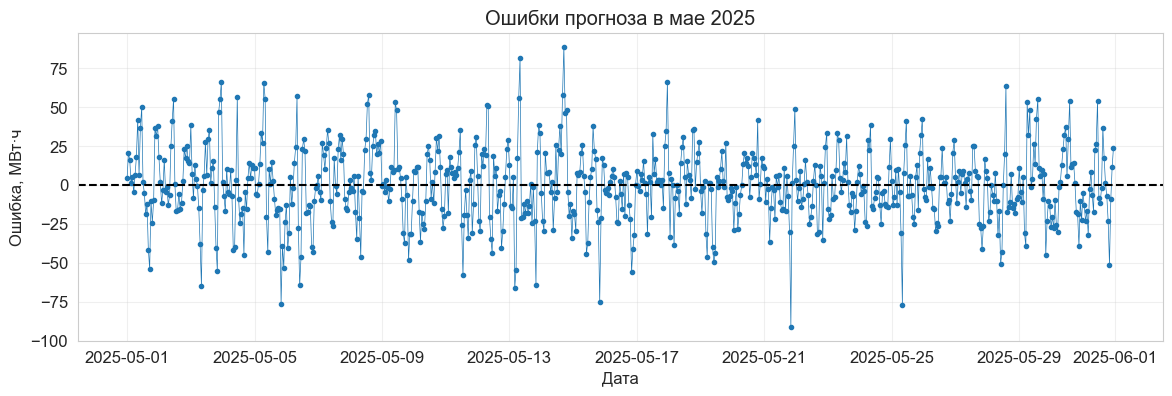

Средняя ошибка по дням мая:
day
1     5.510997
2     6.137704
3     5.055138
4    -5.303064
5    -4.627585
6    -9.203927
7     6.628493
8     9.935620
9    -2.524644
10   -0.497459
11   -0.570328
12    0.516074
13   -4.643993
14    9.034555
15   -4.332013
16   -9.625715
17    6.583836
18    4.927027
19   -8.020421
20    3.973291
21   -6.742511
22   -3.138763
23   -0.455773
24   -1.815761
25   -0.585342
26   -2.737284
27   -1.097406
28   -8.885665
29    5.641130
30   -0.639483
31   -1.208128
Name: error, dtype: float64


In [74]:
# =============================================================================
# 9. ОЦЕНКА МОДЕЛИ (MAE, RMSE, MAPE, MASE)
# =============================================================================

if df_test_with_pred is not None and not df_test_with_pred.empty:
    print("\n" + "=" * 50)
    print("ОЦЕНКА ТОЧНОСТИ ПРОГНОЗА")
    print("=" * 50)

    y_true = df_test_with_pred['y'].values
    y_pred = df_test_with_pred['y_pred'].values

    mae = MAE(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = MAPE(y_true, y_pred) * 100

    # Расчёт MASE: наивный сезонный прогноз с лагом 168 часов (недельная сезонность)
    df_test_with_pred['naive'] = df_test_with_pred['y'].shift(168)
    naive_errors = abs(df_test_with_pred['y'] - df_test_with_pred['naive']).dropna()
    mae_naive = naive_errors.mean()
    mase = mae / mae_naive if mae_naive > 0 else np.nan

    print(f"MAE  = {mae:.3f} МВт·ч")
    print(f"RMSE = {rmse:.3f} МВт·ч")
    print(f"MAPE = {mape:.3f} %")
    print(f"MASE = {mase:.3f}")

    if mape < 1.3:
        print("✅ Требование MAPE < 1.3% выполнено!")
    else:
        print("⚠️ Требование MAPE < 1.3% не выполнено, требуется донастройка.")

    # Сохраняем метрики
    metrics_file = os.path.join(RESULTS_DIR, 'metrics.txt')
    with open(metrics_file, 'w', encoding='utf-8') as f:
        f.write(f"MAE  = {mae:.3f} МВт·ч\n")
        f.write(f"RMSE = {rmse:.3f} МВт·ч\n")
        f.write(f"MAPE = {mape:.3f} %\n")
        f.write(f"MASE = {mase:.3f}\n")
        f.write(f"Дата расчёта: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
else:
    print("Нет данных для оценки модели.")

print("\nПомесячные метрики:")
for month in range(1,6):
    month_data = df_test_with_pred[df_test_with_pred['ds'].dt.month == month]
    if len(month_data) > 0:
        mae_m = MAE(month_data['y'], month_data['y_pred'])
        mape_m = MAPE(month_data['y'], month_data['y_pred']) * 100
        print(f"Месяц {month}: MAE={mae_m:.2f}, MAPE={mape_m:.2f}%")

# Анализ ошибок в мае
# График помогает выявить дни с систематическими ошибками
# (например, 1–9 мая или резкие скачки в середине месяца),
# что даёт основу для дальнейшего улучшения модели.
may_data = df_test_with_pred[df_test_with_pred['ds'].dt.month == 5].copy()
may_data['error'] = may_data['y'] - may_data['y_pred']
may_data['day'] = may_data['ds'].dt.day

plt.figure(figsize=(14,4))
plt.plot(may_data['ds'], may_data['error'], marker='o', markersize=3, linestyle='-', linewidth=0.5)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Ошибки прогноза в мае 2025')
plt.xlabel('Дата')
plt.ylabel('Ошибка, МВт·ч')
plt.grid(True, alpha=0.3)
plt.show()

# Средняя ошибка по дням
day_errors = may_data.groupby('day')['error'].mean()
print("Средняя ошибка по дням мая:")
print(day_errors)

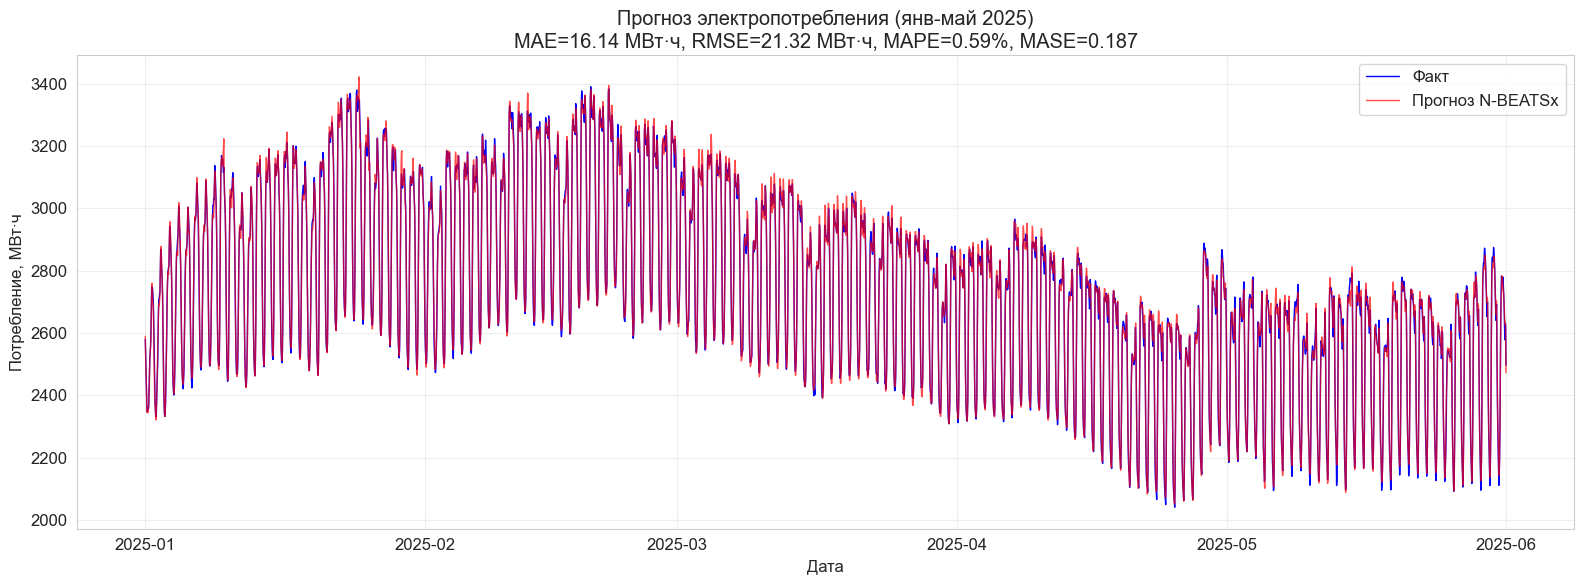

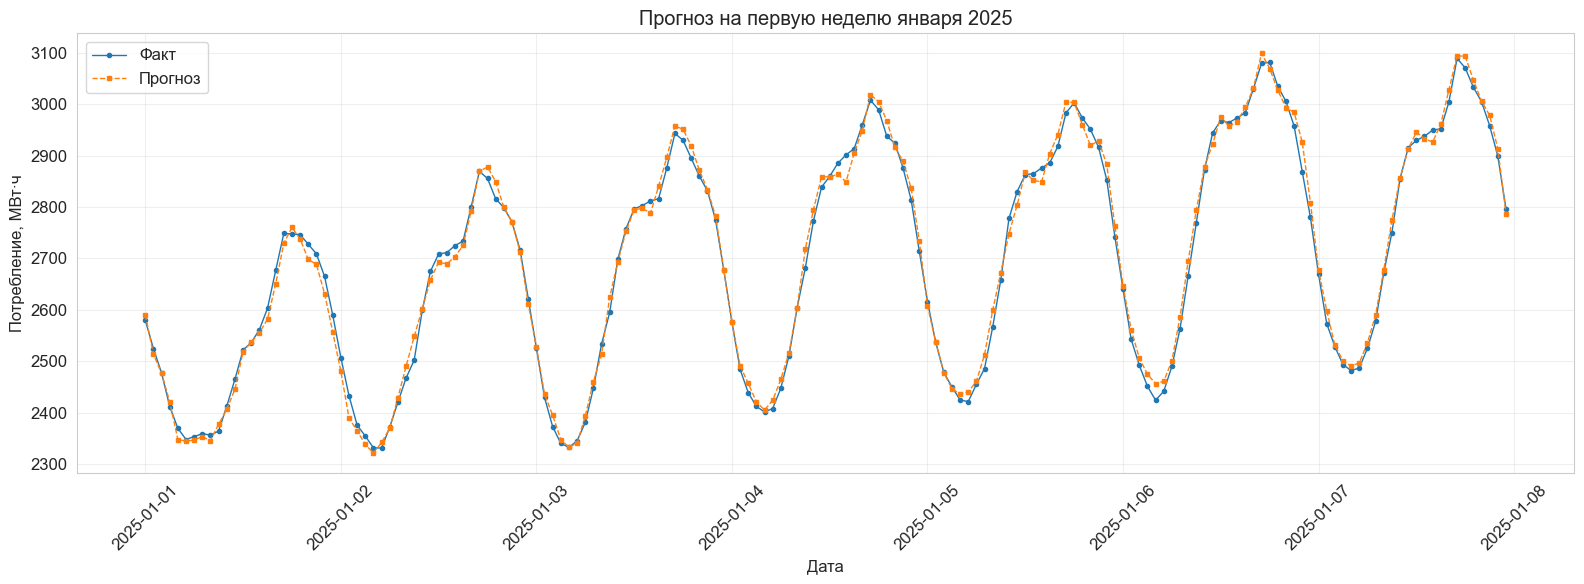

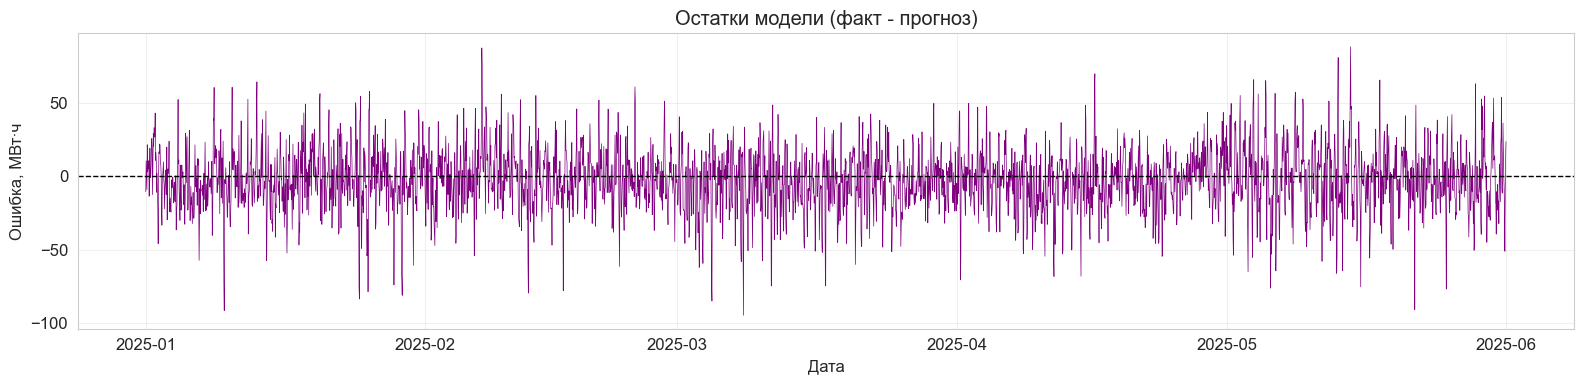

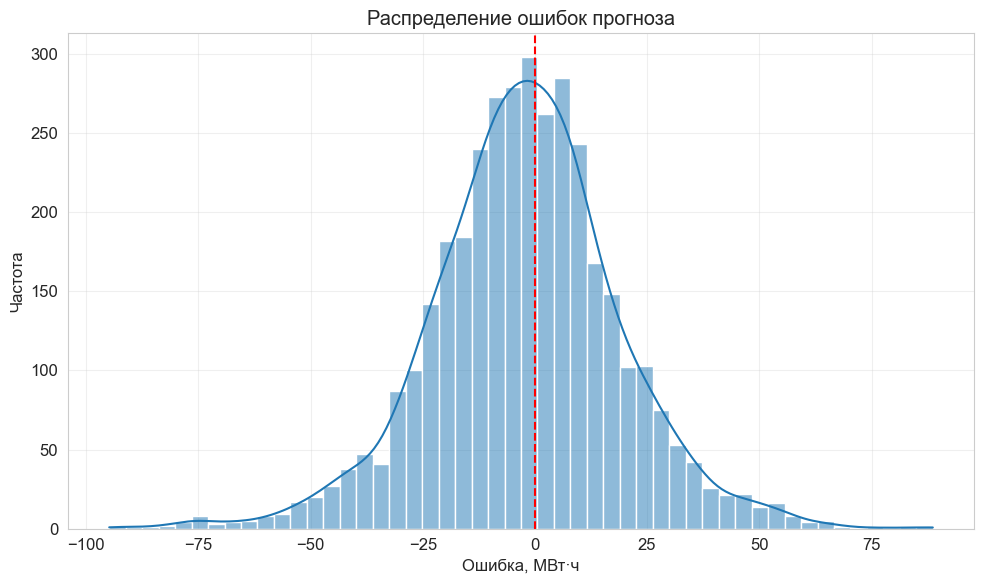

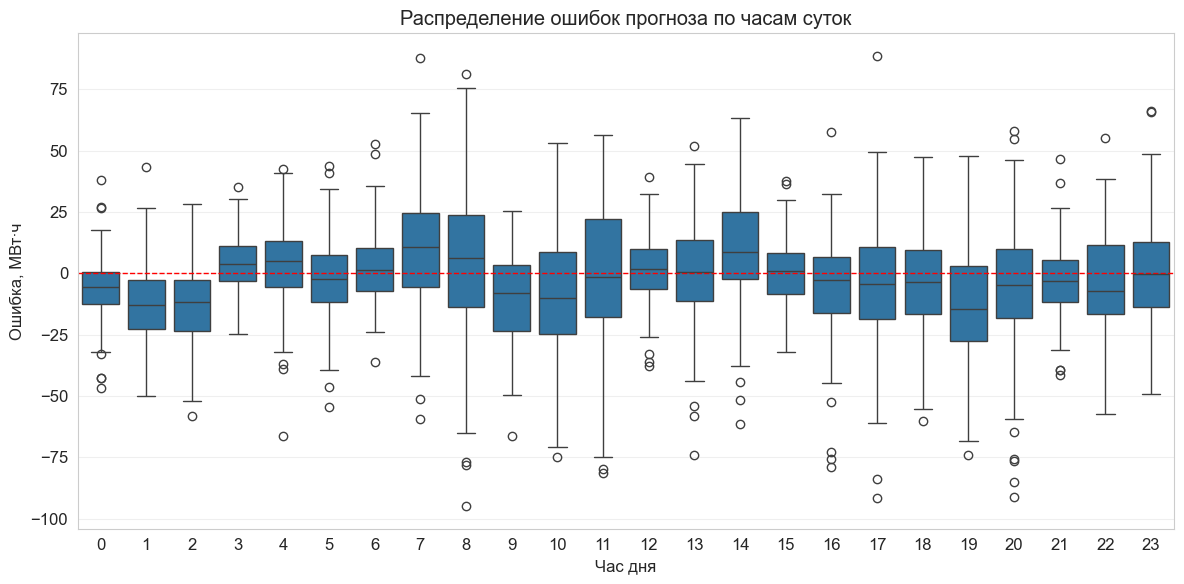


Все результаты сохранены в папке: run_20260319_220021


In [75]:
# =============================================================================
# 10. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# =============================================================================

if df_test_with_pred is not None and not df_test_with_pred.empty:
    # 10.1 Прогноз vs факт за весь тестовый период
    plt.figure(figsize=(16, 6))
    plt.plot(df_test_with_pred['ds'], df_test_with_pred['y'], label='Факт', linewidth=1, color='blue')
    plt.plot(df_test_with_pred['ds'], df_test_with_pred['y_pred'], label='Прогноз N-BEATSx', linewidth=1, color='red', alpha=0.7)
    plt.title(f'Прогноз электропотребления (янв-май 2025)\nMAE={mae:.2f} МВт·ч, RMSE={rmse:.2f} МВт·ч, MAPE={mape:.2f}%, MASE={mase:.3f}')
    plt.xlabel('Дата')
    plt.ylabel('Потребление, МВт·ч')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PICTURES_DIR, '07_forecast_vs_actual_full_test.png'), dpi=300)
    plt.show()

    # 10.2 Первая неделя января
    plot_start = datetime(2025, 1, 1)
    plot_end = datetime(2025, 1, 7, 23, 0, 0)
    plot_df = df_test_with_pred[(df_test_with_pred['ds'] >= plot_start) & (df_test_with_pred['ds'] <= plot_end)]
    plt.figure(figsize=(16, 6))
    plt.plot(plot_df['ds'], plot_df['y'], 'o-', label='Факт', markersize=3, linewidth=1)
    plt.plot(plot_df['ds'], plot_df['y_pred'], 's--', label='Прогноз', markersize=3, linewidth=1)
    plt.title('Прогноз на первую неделю января 2025')
    plt.xlabel('Дата')
    plt.ylabel('Потребление, МВт·ч')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(PICTURES_DIR, '08_forecast_week_jan2025.png'), dpi=300)
    plt.show()

    # 10.3 Остатки
    df_test_with_pred['error'] = df_test_with_pred['y'] - df_test_with_pred['y_pred']
    plt.figure(figsize=(16, 4))
    plt.plot(df_test_with_pred['ds'], df_test_with_pred['error'], color='purple', linewidth=0.5)
    plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
    plt.title('Остатки модели (факт - прогноз)')
    plt.xlabel('Дата')
    plt.ylabel('Ошибка, МВт·ч')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PICTURES_DIR, '09_residuals.png'), dpi=300)
    plt.show()

    # 10.4 Гистограмма ошибок
    plt.figure(figsize=(10, 6))
    sns.histplot(df_test_with_pred['error'], bins=50, kde=True)
    plt.title('Распределение ошибок прогноза')
    plt.xlabel('Ошибка, МВт·ч')
    plt.ylabel('Частота')
    plt.axvline(x=0, color='red', linestyle='--')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PICTURES_DIR, '10_error_distribution.png'), dpi=300)
    plt.show()

    # 10.5 Ошибки по часам
    df_test_with_pred['Hour'] = df_test_with_pred['ds'].dt.hour
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_test_with_pred, x='Hour', y='error')
    plt.title('Распределение ошибок прогноза по часам суток')
    plt.xlabel('Час дня')
    plt.ylabel('Ошибка, МВт·ч')
    plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PICTURES_DIR, '11_error_by_hour.png'), dpi=300)
    plt.show()

    print(f"\nВсе результаты сохранены в папке: {RUN_DIR}")
else:
    print("Нет данных для визуализации.")